In [3]:
import numpy as np
import tensorflow as tf
import keras
from keras.models import load_model
from keras.layers import Dense,Dropout,Activation,Add,MaxPooling2D,Conv2D,Flatten,BatchNormalization,MaxPool2D
from keras.models import Sequential
import matplotlib.pyplot as plt

In [2]:
#Getting data
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "Accumulated", labels='inferred', label_mode="categorical", class_names=None,
    color_mode="grayscale", batch_size=32, image_size=(28, 28), shuffle=True, seed=123,
    validation_split=0.2, subset="training"
)
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "Accumulated", labels='inferred', label_mode="categorical", class_names=None,
    color_mode="grayscale", batch_size=32, image_size=(28, 28), shuffle=True, seed=123,
    validation_split=0.2, subset="validation"
)

Found 10600 files belonging to 7 classes.
Using 8480 files for training.
Found 10600 files belonging to 7 classes.
Using 2120 files for validation.


In [34]:
#Loading MNIST model as base
model = load_model('mnistModel')
model.layers[0].trainable = False
model.layers[1].trainable = False
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 64)        640       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 13, 13, 64)        0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 10816)             0         
_________________________________________________________________
dense_2 (Dense)              (None, 128)               1384576   
_________________________________________________________________
dense_3 (Dense)              (None, 10)                1290      
Total params: 1,386,506
Trainable params: 1,385,866
Non-trainable params: 640
_________________________________________________________________


In [35]:
#Creating new model
TL_Model = Sequential()
TL_Model.add(model.layers[0])
TL_Model.add(model.layers[1])
TL_Model.add(Conv2D(16, kernel_size = (3, 3), activation = 'relu',name='c2'))
TL_Model.add(MaxPooling2D(pool_size = (2, 2),name ='m2'))
TL_Model.add(Flatten())
TL_Model.add(Dense(64,activation = 'relu'))
TL_Model.add(Dense(7,activation='softmax'))

In [36]:
#Model compilation
TL_Model.compile(optimizer='Adam', metrics=['accuracy'], loss='categorical_crossentropy')
call = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True)

In [37]:
#Training the model
fit = TL_Model.fit(train_data,validation_data=val_data,epochs=10,callbacks=[call])

Epoch 1/10
265/265 [==============================] - 17s 66ms/step - loss: 1.0071 - accuracy: 0.6730 - val_loss: 0.5207 - val_accuracy: 0.7637
Epoch 2/10
265/265 [==============================] - 17s 65ms/step - loss: 0.3773 - accuracy: 0.8085 - val_loss: 0.3400 - val_accuracy: 0.8156
Epoch 3/10
265/265 [==============================] - 17s 64ms/step - loss: 0.2751 - accuracy: 0.8389 - val_loss: 0.3032 - val_accuracy: 0.8123
Epoch 4/10
265/265 [==============================] - 17s 64ms/step - loss: 0.2395 - accuracy: 0.8433 - val_loss: 0.2881 - val_accuracy: 0.8137
Epoch 5/10
265/265 [==============================] - 17s 65ms/step - loss: 0.2199 - accuracy: 0.8509 - val_loss: 0.3036 - val_accuracy: 0.8127
Epoch 6/10
265/265 [==============================] - 18s 66ms/step - loss: 0.2105 - accuracy: 0.8559 - val_loss: 0.2692 - val_accuracy: 0.8160
Epoch 7/10
265/265 [==============================] - 17s 65ms/step - loss: 0.2039 - accuracy: 0.8570 - val_loss: 0.2711 - val_accuracy:

In [38]:
#Data for plots
acc = fit.history['accuracy']
val_acc = fit.history['val_accuracy']
loss = fit.history['loss']
val_loss = fit.history['val_loss']
epochs = range(1, len(loss) + 1)

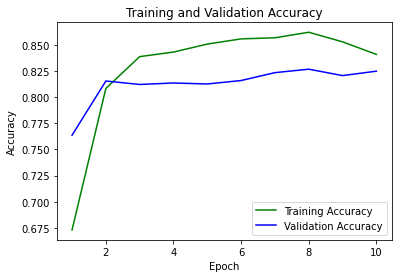

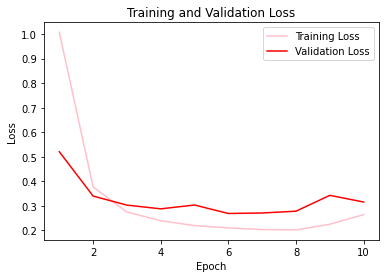

<Figure size 432x288 with 0 Axes>

In [39]:
#accuracy plot
plt.plot(epochs, acc, color='green', label='Training Accuracy')
plt.plot(epochs, val_acc, color='blue', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.figure()
#loss plot
plt.plot(epochs, loss, color='pink', label='Training Loss')
plt.plot(epochs, val_loss, color='red', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.figure()
plt.show()